# Age Classification - 5-Fold Cross Validation on 31 Videos
## Using Fine-tuned Model (age_classifier.pth)

**Method:** Video-based split (no overlap between folds)
**Model:** Previously fine-tuned EfficientNet-B0
**Videos:** 31 videos split into 5 folds (~6-7 videos each)

## Step 1: Setup

In [1]:
!pip install torch torchvision timm scikit-learn seaborn -q

from google.colab import drive
drive.mount('/content/drive')

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm
import pandas as pd
import numpy as np
from pathlib import Path
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✓ Using: {device}")

Mounted at /content/drive
✓ Using: cuda


## Step 2: Configuration

In [2]:
BASE_PATH = Path("/content/drive/MyDrive/face_pipeline_project")
FACE_CROPS_FOLDER = BASE_PATH / "face_crops_aligned"  # Contains 31 video subfolders
MODEL_PATH = BASE_PATH / "models/age_classifier.pth"  # Previously fine-tuned model
METRICS_FOLDER = BASE_PATH / "metrics"

METRICS_FOLDER.mkdir(exist_ok=True, parents=True)

N_FOLDS = 5
BATCH_SIZE = 32
IMAGE_SIZE = 224

print(f"Face crops folder: {FACE_CROPS_FOLDER}")
print(f"Model: {MODEL_PATH}")
print(f"Number of folds: {N_FOLDS}")

Face crops folder: /content/drive/MyDrive/face_pipeline_project/face_crops_aligned
Model: /content/drive/MyDrive/face_pipeline_project/models/age_classifier.pth
Number of folds: 5


## Step 3: Load Fine-tuned Model

In [3]:
model = timm.create_model('efficientnet_b0', pretrained=False, num_classes=2)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model = model.to(device)
model.eval()

print("✓ Fine-tuned model loaded")

✓ Fine-tuned model loaded


## Step 4: Scan All Face Crops from 31 Videos

In [4]:
print("Scanning face crops from all video folders...")

all_data = []
video_folders = sorted([f for f in FACE_CROPS_FOLDER.iterdir() if f.is_dir()])

print(f"Found {len(video_folders)} video folders")

for video_folder in tqdm(video_folders, desc="Scanning videos"):
    video_name = video_folder.name
    face_files = list(video_folder.glob("*.jpg")) + list(video_folder.glob("*.png"))

    for face_file in face_files:
        all_data.append({
            'video': video_name,
            'face_file': face_file.name,
            'image_path': str(face_file)
        })

df = pd.DataFrame(all_data)
print(f"\n✓ Total face crops found: {len(df)}")
print(f"✓ Total videos: {df['video'].nunique()}")

# Show samples per video
print(f"\nSamples per video:")
video_counts = df['video'].value_counts()
print(video_counts.head(10))
if len(video_counts) > 10:
    print(f"... and {len(video_counts) - 10} more videos")

Scanning face crops from all video folders...
Found 31 video folders


Scanning videos: 100%|██████████| 31/31 [00:33<00:00,  1.07s/it]


✓ Total face crops found: 30819
✓ Total videos: 31

Samples per video:
video
10.01.00-11.05.46[M][0@0][117548]_ch1       3745
09.14.00-10.18.46[M][0@0][126501]_ch1       3709
11.38.48-12.23.10[M][0@0][56580]_ch1        3377
14.13.01-14.47.06[M][0@0][121423]_ch1       1926
09.45.37-10.32.00[M][0@0][107760]_ch1       1822
10.22.49-10.55.40[M][0@0][98666]_ch1        1662
10.13.48-10.56.00[M][0@0][55269]_ch1        1513
15.11.15-15.36.03[M][0@0][16572]_ch1        1147
11.07.48-11.40.41[M][0@0][99358]_ch1 (1)    1125
10.39.58-11.07.55[M][0@0][51053]_ch1        1110
Name: count, dtype: int64
... and 21 more videos


## Step 5: Create Video-Based 5 Folds (No Overlap)

In [5]:
# Get unique videos
videos = df['video'].unique()
n_videos = len(videos)

print(f"Total videos: {n_videos}")

# Shuffle videos with fixed seed for reproducibility
np.random.seed(42)
np.random.shuffle(videos)

# Split into N_FOLDS groups
fold_size = n_videos // N_FOLDS
video_folds = []

for i in range(N_FOLDS):
    if i == N_FOLDS - 1:
        # Last fold gets remaining videos
        fold_videos = videos[i * fold_size:]
    else:
        fold_videos = videos[i * fold_size:(i + 1) * fold_size]
    video_folds.append(list(fold_videos))

    # Count faces in this fold
    fold_faces = len(df[df['video'].isin(fold_videos)])
    print(f"Fold {i+1}: {len(fold_videos)} videos, {fold_faces} faces")

# Verify no overlap
all_fold_videos = [v for fold in video_folds for v in fold]
assert len(all_fold_videos) == len(set(all_fold_videos)), "Overlap detected!"
print(f"\n✓ 5 folds created with NO video overlap")

Total videos: 31
Fold 1: 6 videos, 8521 faces
Fold 2: 6 videos, 4593 faces
Fold 3: 6 videos, 7398 faces
Fold 4: 6 videos, 1915 faces
Fold 5: 7 videos, 8392 faces

✓ 5 folds created with NO video overlap


## Step 6: Dataset & Transform

In [6]:
class FaceDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            image = Image.open(row['image_path']).convert('RGB')
            if self.transform:
                image = self.transform(image)
            return image, row['image_path'], row['video']
        except Exception as e:
            # Return a blank image if file is corrupted
            image = Image.new('RGB', (IMAGE_SIZE, IMAGE_SIZE), (128, 128, 128))
            if self.transform:
                image = self.transform(image)
            return image, row['image_path'], row['video']

transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

print("✓ Dataset class ready")

✓ Dataset class ready


## Step 7: Run 5-Fold Inference

In [7]:
fold_results = []
all_predictions = []

CLASS_NAMES = ['child', 'adult']

for fold_num in range(1, N_FOLDS + 1):
    fold_videos = video_folds[fold_num - 1]
    fold_df = df[df['video'].isin(fold_videos)].copy()

    print(f"\n{'='*60}")
    print(f"FOLD {fold_num}: {len(fold_videos)} videos, {len(fold_df)} faces")
    print(f"{'='*60}")
    print(f"Videos: {', '.join(fold_videos[:3])}..." if len(fold_videos) > 3 else f"Videos: {', '.join(fold_videos)}")

    # Create dataset and loader
    fold_dataset = FaceDataset(fold_df, transform)
    fold_loader = DataLoader(fold_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    fold_preds = []
    fold_paths = []
    fold_videos_list = []

    with torch.no_grad():
        for images, paths, videos_batch in tqdm(fold_loader, desc=f"Fold {fold_num}"):
            images = images.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            fold_preds.extend(predicted.cpu().numpy())
            fold_paths.extend(paths)
            fold_videos_list.extend(videos_batch)

    # Count predictions
    pred_counts = Counter(fold_preds)
    n_child = pred_counts.get(0, 0)
    n_adult = pred_counts.get(1, 0)
    total = n_child + n_adult

    fold_results.append({
        'fold': fold_num,
        'videos': len(fold_videos),
        'total_faces': total,
        'child_count': n_child,
        'adult_count': n_adult,
        'child_pct': n_child / total * 100 if total > 0 else 0,
        'adult_pct': n_adult / total * 100 if total > 0 else 0
    })

    # Store predictions
    for path, video, pred in zip(fold_paths, fold_videos_list, fold_preds):
        all_predictions.append({
            'fold': fold_num,
            'video': video,
            'image_path': path,
            'prediction': CLASS_NAMES[pred],
            'prediction_int': pred
        })

    print(f"  Child: {n_child} ({n_child/total*100:.1f}%)")
    print(f"  Adult: {n_adult} ({n_adult/total*100:.1f}%)")

print("\n✓ All folds complete")


FOLD 1: 6 videos, 8521 faces
Videos: 15.11.15-15.36.03[M][0@0][16572]_ch1, 11.05.24-12.08.25[M][0@0][22489]_ch1, 14.11.39-14.25.32[M][0@0][87881]_ch1...


Fold 1: 100%|██████████| 267/267 [16:52<00:00,  3.79s/it]


  Child: 1665 (19.5%)
  Adult: 6856 (80.5%)

FOLD 2: 6 videos, 4593 faces
Videos: 15.52.42-16.07.48[M][0@0][17210]_ch1, 14.13.01-14.47.06[M][0@0][121423]_ch1, 10.28.56-10.53.00[M][0@0][65180]_ch1...


Fold 2: 100%|██████████| 144/144 [15:00<00:00,  6.25s/it]


  Child: 811 (17.7%)
  Adult: 3782 (82.3%)

FOLD 3: 6 videos, 7398 faces
Videos: 09.45.02-10.09.54[M][0@0][74131]_ch1, 10.39.58-11.07.55[M][0@0][51053]_ch1, 10.25.54-11.30.31[M][0@0][127610]_ch1...


...

  Child: 2096 (28.3%)
  Adult: 5302 (71.7%)

FOLD 4: 6 videos, 1915 faces
Videos: 14.26.49-14.50.52[M][0@0][35125]_ch1, 09.21.03-09.33.00[M][0@0][64136]_ch1, 12.19.31-12.51.26[M][0@0][42821]_ch1...


Fold 4: 100%|██████████| 60/60 [06:13<00:00,  6.23s/it]


  Child: 1143 (59.7%)
  Adult: 772 (40.3%)

FOLD 5: 7 videos, 8392 faces
Videos: 11.38.48-12.23.10[M][0@0][56580]_ch1, 09.47.48-10.16.47[M][0@0][83838]_ch1, 10.22.49-10.55.40[M][0@0][98666]_ch1...


Fold 5: 100%|██████████| 263/263 [27:36<00:00,  6.30s/it]

  Child: 1011 (12.0%)
  Adult: 7381 (88.0%)

✓ All folds complete


## Step 8: Results Summary

In [8]:
results_df = pd.DataFrame(fold_results)

print("\n" + "="*70)
print("5-FOLD CROSS VALIDATION RESULTS (31 Videos, No Overlap)")
print("="*70)
print(results_df.to_string(index=False))

# Overall statistics
total_faces = results_df['total_faces'].sum()
total_child = results_df['child_count'].sum()
total_adult = results_df['adult_count'].sum()

mean_child_pct = results_df['child_pct'].mean()
std_child_pct = results_df['child_pct'].std()

print(f"\n" + "="*40)
print(f"OVERALL SUMMARY")
print(f"="*40)
print(f"Total Videos: {results_df['videos'].sum()}")
print(f"Total Faces: {total_faces}")
print(f"Total Children: {total_child} ({total_child/total_faces*100:.1f}%)")
print(f"Total Adults: {total_adult} ({total_adult/total_faces*100:.1f}%)")
print(f"\nChild % (Mean ± Std): {mean_child_pct:.1f}% ± {std_child_pct:.1f}%")

# Save results
results_df.to_csv(METRICS_FOLDER / "cv_5fold_31videos_results.csv", index=False)
print(f"\n✓ Results saved to: {METRICS_FOLDER / 'cv_5fold_31videos_results.csv'}")


5-FOLD CROSS VALIDATION RESULTS (31 Videos, No Overlap)
 fold  videos  total_faces  child_count  adult_count  child_pct  adult_pct
    1       6         8521         1665         6856  19.539960  80.460040
    2       6         4593          811         3782  17.657305  82.342695
    3       6         7398         2096         5302  28.331982  71.668018
    4       6         1915         1143          772  59.686684  40.313316
    5       7         8392         1011         7381  12.047188  87.952812

OVERALL SUMMARY
Total Videos: 31
Total Faces: 30819
Total Children: 6726 (21.8%)
Total Adults: 24093 (78.2%)

Child % (Mean ± Std): 27.5% ± 18.9%

✓ Results saved to: /content/drive/MyDrive/face_pipeline_project/metrics/cv_5fold_31videos_results.csv


## Step 9: Visualizations

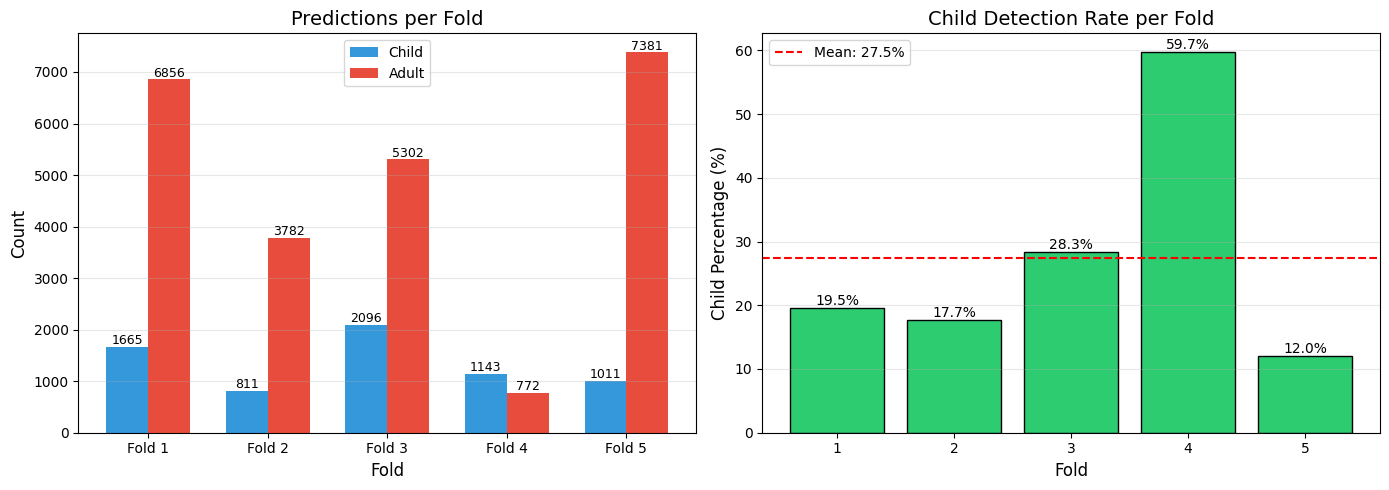

✓ Visualization saved


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Predictions per Fold
ax1 = axes[0]
x = np.arange(N_FOLDS)
width = 0.35

bars1 = ax1.bar(x - width/2, results_df['child_count'], width, label='Child', color='#3498db')
bars2 = ax1.bar(x + width/2, results_df['adult_count'], width, label='Adult', color='#e74c3c')

ax1.set_xlabel('Fold', fontsize=12)
ax1.set_ylabel('Count', fontsize=12)
ax1.set_title('Predictions per Fold', fontsize=14)
ax1.set_xticks(x)
ax1.set_xticklabels([f'Fold {i+1}' for i in range(N_FOLDS)])
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Add value labels
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{int(bar.get_height())}', ha='center', fontsize=9)
for bar in bars2:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{int(bar.get_height())}', ha='center', fontsize=9)

# Plot 2: Child Percentage per Fold
ax2 = axes[1]
bars = ax2.bar(range(1, N_FOLDS + 1), results_df['child_pct'], color='#2ecc71', edgecolor='black')
ax2.axhline(y=mean_child_pct, color='red', linestyle='--', label=f'Mean: {mean_child_pct:.1f}%')

ax2.set_xlabel('Fold', fontsize=12)
ax2.set_ylabel('Child Percentage (%)', fontsize=12)
ax2.set_title('Child Detection Rate per Fold', fontsize=14)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Add value labels
for i, bar in enumerate(bars):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{results_df["child_pct"].iloc[i]:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(METRICS_FOLDER / "cv_5fold_31videos_visualization.png", dpi=150)
plt.show()

print(f"✓ Visualization saved")

## Step 10: Per-Video Statistics

In [10]:
# Create predictions dataframe
pred_df = pd.DataFrame(all_predictions)

# Per-video summary
video_stats = pred_df.groupby(['fold', 'video']).agg({
    'prediction_int': ['count', 'sum', 'mean']
}).reset_index()
video_stats.columns = ['fold', 'video', 'total', 'adult_count', 'adult_ratio']
video_stats['child_count'] = video_stats['total'] - video_stats['adult_count']
video_stats['child_ratio'] = 1 - video_stats['adult_ratio']

print("Per-Video Statistics:")
print(video_stats.to_string(index=False))

# Save detailed results
pred_df.to_csv(METRICS_FOLDER / "cv_5fold_all_predictions.csv", index=False)
video_stats.to_csv(METRICS_FOLDER / "cv_5fold_per_video_stats.csv", index=False)

print(f"\n✓ Detailed predictions saved to: {METRICS_FOLDER / 'cv_5fold_all_predictions.csv'}")
print(f"✓ Per-video stats saved to: {METRICS_FOLDER / 'cv_5fold_per_video_stats.csv'}")

Per-Video Statistics:
 fold                                    video  total  adult_count  adult_ratio  child_count  child_ratio
    1    10.01.00-11.05.46[M][0@0][117548]_ch1   3745         3372     0.900401          373     0.099599
    1     10.13.48-10.56.00[M][0@0][55269]_ch1   1513          923     0.610046          590     0.389954
    1     11.05.24-12.08.25[M][0@0][22489]_ch1    703          356     0.506401          347     0.493599
    1 11.07.48-11.40.41[M][0@0][99358]_ch1 (1)   1125          888     0.789333          237     0.210667
    1     14.11.39-14.25.32[M][0@0][87881]_ch1    288          220     0.763889           68     0.236111
    1     15.11.15-15.36.03[M][0@0][16572]_ch1   1147         1097     0.956408           50     0.043592
    2    08.56.26-09.18.33[M][0@0][107006]_ch1    557          355     0.637343          202     0.362657
    2     09.22.21-09.37.43[M][0@0][54476]_ch1    665          548     0.824060          117     0.175940
    2     10.28.56-10.53

## Step 11: Overall Distribution Pie Chart

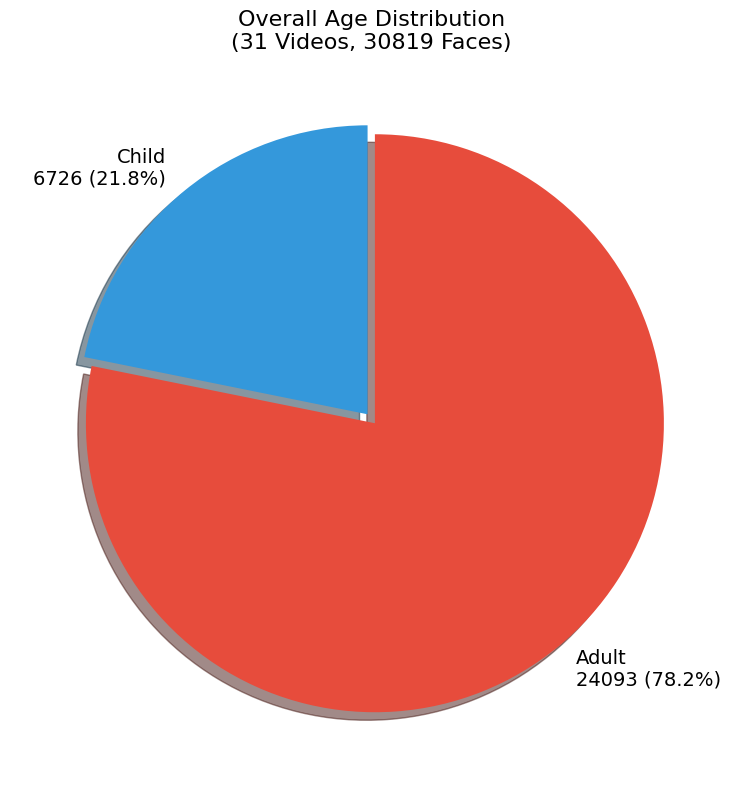

✓ Distribution chart saved


In [11]:
fig, ax = plt.subplots(figsize=(8, 8))

sizes = [total_child, total_adult]
labels = [f'Child\n{total_child} ({total_child/total_faces*100:.1f}%)',
          f'Adult\n{total_adult} ({total_adult/total_faces*100:.1f}%)']
colors = ['#3498db', '#e74c3c']
explode = (0.02, 0.02)

ax.pie(sizes, explode=explode, labels=labels, colors=colors,
       autopct='', shadow=True, startangle=90,
       textprops={'fontsize': 14})
ax.set_title(f'Overall Age Distribution\n(31 Videos, {total_faces} Faces)', fontsize=16)

plt.tight_layout()
plt.savefig(METRICS_FOLDER / "cv_5fold_overall_distribution.png", dpi=150)
plt.show()

print("✓ Distribution chart saved")

---
## ✅ Complete!

**5-Fold Cross Validation on 31 Videos (No Overlap)**

**Output Files:**
- `cv_5fold_31videos_results.csv` - Per-fold summary
- `cv_5fold_all_predictions.csv` - All individual predictions
- `cv_5fold_per_video_stats.csv` - Per-video statistics
- `cv_5fold_31videos_visualization.png` - Bar charts
- `cv_5fold_overall_distribution.png` - Pie chart

**Note:** This shows prediction distribution across folds. For accuracy metrics, you would need ground-truth labels.